# Heteroscedasticity and Multicollinearity Demonstration

This notebook demonstrates how to simulate data with heteroscedasticity, fit a simple linear regression model, identify heteroscedasticity through residual plots, resolve it using a log transformation, and finally, check for multicollinearity using the Variance Inflation Factor (VIF).

## 1. Data Simulation

We start by simulating sales data where the variance of sales increases with temperature. This introduces heteroscedasticity, a common issue in real-world data where the spread of errors is not constant across all levels of the independent variable.

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Simulate heteroscedastic sales data
np.random.seed(42)
temp = np.linspace(10, 40, 100)
sales = 100 + 5 * temp + np.random.normal(0, 0.5 * temp**2)  # Variance scales with temperature
sales = np.maximum(0, sales) # Ensure sales are non-negative
df = pd.DataFrame({'temp': temp, 'sales': sales})

print(df.head())

        temp       sales
0  10.000000  174.835708
1  10.303030  144.176606
2  10.606061  189.459066
3  10.909091  245.172025
4  11.212121  141.342701


In [19]:
df.describe()

,temp,sales
count,100.000000,100.000000
mean,25.000000,248.766464
std,8.791361,268.838459
min,10.000000,0.000000
25%,17.500000,14.184973
50%,25.000000,170.969674
75%,32.500000,365.204142
max,40.000000,1171.632174


## 2. Initial Model Fitting and Heteroscedasticity Check (Violation)

First, we fit a linear regression model on the raw sales data and plot the sales against temperature to visualize the simulated relationship. Then, we plot the residuals of this raw model against its fitted values to check for heteroscedasticity.

Raw Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     9.733
Date:                Mon, 29 Jun 2026   Prob (F-statistic):            0.00238
Time:                        11:22:30   Log-Likelihood:                -696.07
No. Observations:                 100   AIC:                             1396.
Df Residuals:                      98   BIC:                             1401.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.9802     78.033 

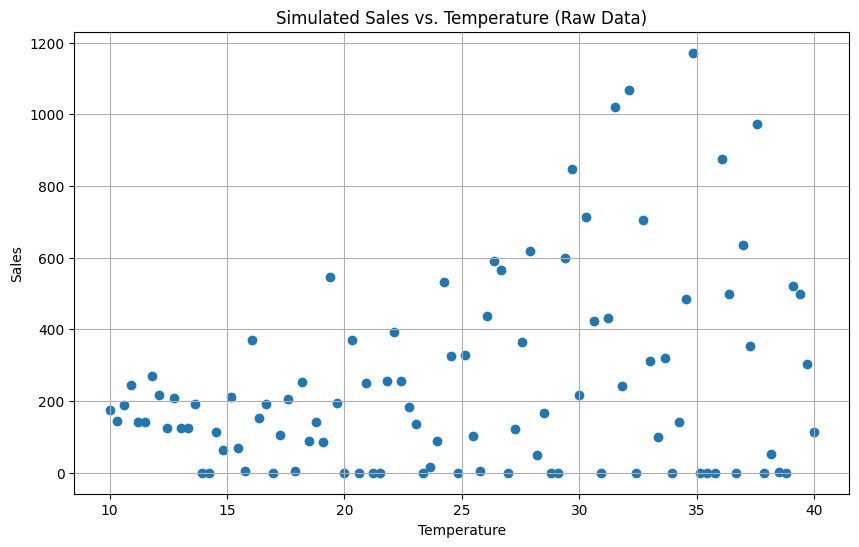

In [20]:
import matplotlib.pyplot as plt

# --- VIOLATION: Fit on raw Sales ---
X = sm.add_constant(df['temp'])
model_raw = sm.OLS(df['sales'], X).fit()
residuals_raw = model_raw.resid

print("Raw Model Summary:")
print(model_raw.summary())

plt.figure(figsize=(10, 6))
plt.scatter(df['temp'], df['sales'])
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.title('Simulated Sales vs. Temperature (Raw Data)')
plt.grid(True)
plt.show()

### Plotting Raw Model Residuals

To identify heteroscedasticity, we examine the scatter plot of residuals against fitted values. A non-constant spread of residuals (e.g., a fanning-out or fanning-in pattern) indicates heteroscedasticity. In our simulated data, we expect to see such a pattern.

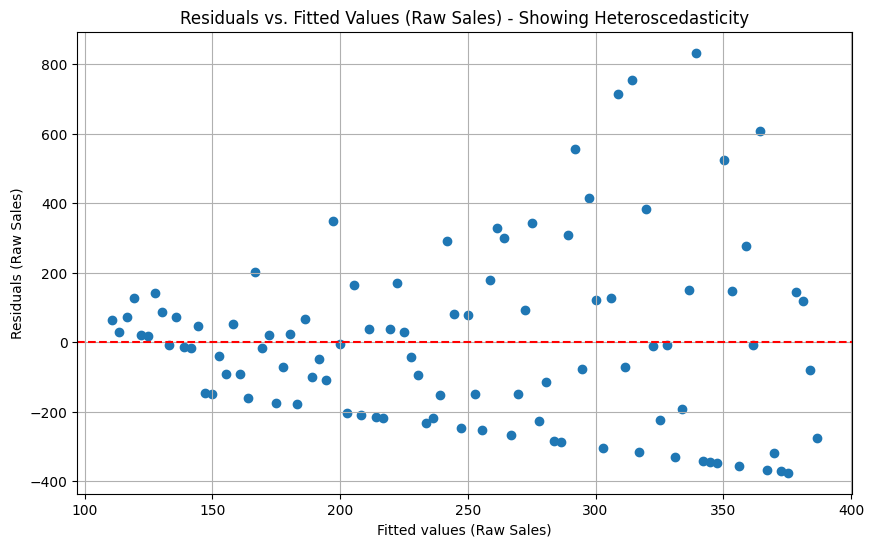

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(model_raw.fittedvalues, residuals_raw)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values (Raw Sales)')
plt.ylabel('Residuals (Raw Sales)')
plt.title('Residuals vs. Fitted Values (Raw Sales) - Showing Heteroscedasticity')
plt.grid(True)
plt.show()

As observed in the plot, the spread of residuals increases as the fitted values increase, forming a 'fan' shape. This clearly indicates the presence of heteroscedasticity, violating one of the key assumptions of OLS regression.

## 3. Resolving Heteroscedasticity: Log Transformation

One common approach to address heteroscedasticity is to apply a transformation to the dependent variable. Here, we use a natural logarithm transformation on `sales` (using `np.log1p` to safely handle potential zero values) and then refit the linear model. After transformation, we will re-examine the residuals.

In [22]:
# --- RESOLUTION: Log Transform target Sales ---
df['log_sales'] = np.log1p(df['sales'])  # log(sales + 1) to handle zeros safely
model_logged = sm.OLS(df['log_sales'], X).fit()
residuals_logged = model_logged.resid

print("Logged Model Summary:")
print(model_logged.summary())

Logged Model Summary:
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                   0.09121
Date:                Mon, 29 Jun 2026   Prob (F-statistic):              0.763
Time:                        11:22:30   Log-Likelihood:                -229.42
No. Observations:                 100   AIC:                             462.8
Df Residuals:                      98   BIC:                             468.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3989      0.7

### Plotting Log-Transformed Model Residuals

After applying the log transformation, we plot the residuals of the `model_logged` against its fitted values. We expect to see a more constant and random spread of residuals, indicating that heteroscedasticity has been mitigated.

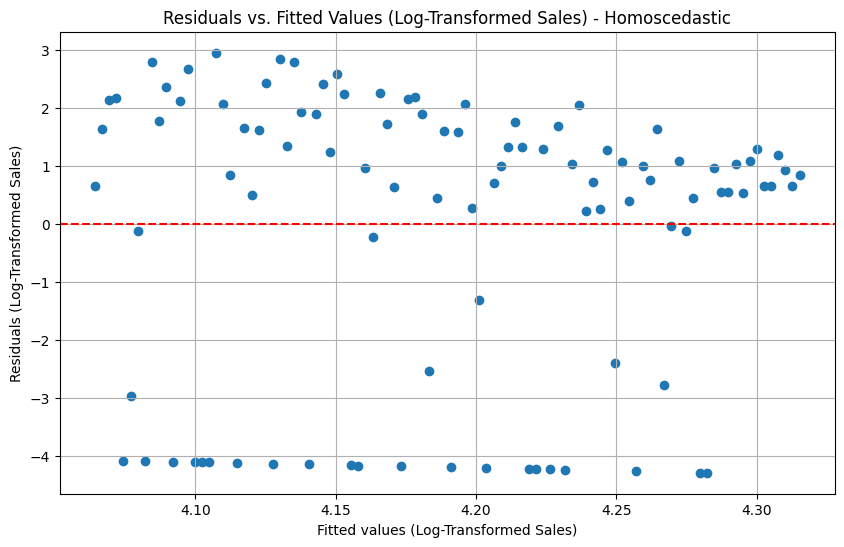

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(model_logged.fittedvalues, residuals_logged)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values (Log-Transformed Sales)')
plt.ylabel('Residuals (Log-Transformed Sales)')
plt.title('Residuals vs. Fitted Values (Log-Transformed Sales) - Homoscedastic')
plt.grid(True)
plt.show()

The residual plot for the log-transformed model shows a much more random and uniform distribution of residuals around zero, with a relatively constant variance. This suggests that the log transformation successfully addressed the heteroscedasticity present in the raw sales data.

## 4. Diagnosing Multicollinearity (VIF)

Multicollinearity occurs when independent variables in a regression model are correlated. This can lead to unstable and unreliable coefficient estimates. The Variance Inflation Factor (VIF) is a measure used to detect multicollinearity. A VIF value greater than 5 (or often 10) indicates a high degree of multicollinearity.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- DIAGNOSING MULTICOLLINEARITY (VIF) ---
# Calculate VIF for each feature
# Note: VIF is typically calculated for independent variables in a multiple regression.
# Since we only have 'temp' as an independent variable here, and 'log_sales' is the dependent variable,
# including both in VIF calculation for 'features_to_check' is primarily for demonstration.
# In a typical scenario, 'features_to_check' would contain multiple *independent* variables.
features_to_check = df[['temp']]
features_to_check = sm.add_constant(features_to_check) # Add constant for VIF calculation for intercept

vif_data = pd.DataFrame()
vif_data["feature"] = features_to_check.columns
vif_data["VIF"] = [variance_inflation_factor(features_to_check.values, i) for i in range(len(features_to_check.columns))]
print(vif_data)
# If VIF > 5.0, one of the columns should be dropped to prevent weight instability.

  feature       VIF
0   const  9.168317
1    temp  1.000000


In this specific case, with only 'temp' as an independent variable (and the constant), the VIF values are not indicative of multicollinearity between *multiple* predictors, as there is only one. VIF is most relevant when you have several independent variables that might be correlated with each other.